In [ ]:
using Pkg
Pkg.activate("..")
Pkg.instantiate()

  Activating project at `d:\TFM code`


In [46]:
include("module/FunctionsNT.jl")

In [ ]:
# Cálculo de los commutadores
N = 50

# Sites: spin-1/2 with quantum numbers
s = siteinds("S=1/2", N; conserve_qns=true)

H_even, H_odd = OpSum_even_odd_Hamiltonian(OpSum_heis_hj, s)
H_even_RLD, H_odd_RLD = OpSum_even_odd_Hamiltonian(OpSum_heis_rf, s)

tau = 10^-1     # Trotter step
tf = 10^3

# log-spaced times from tau to t
n = 100  # number of points
tvec_tau = 10 .^ range(log10(10^-3), log10(tf), length=n)


Cte_old  = mpo_opnorm(comm(H_odd, H_even))
Cte_old_RDL  = mpo_opnorm(comm(H_odd_RLD, H_even_RLD))
Cte_comm = trotter_constants(H_odd, H_even, s, normfun=mpo_opnorm)
Cte_comm_RDL = trotter_constants(H_odd_RLD, H_even_RLD, s, normfun=mpo_opnorm)
nothing

(27.671701390271668, 14.555878868432616, 9.168587480237663, 0.9999999999999973)

In [24]:
errs_tau     = faster_Trotter_error_fixed_tau(Cte_comm, tvec_tau, tau)
errs_old_tau = faster_Trotter_error_fixed_tau_old(Cte_old, tvec_tau, tau)

errs_tau_RLD     = faster_Trotter_error_fixed_tau(Cte_comm_RDL, tvec_tau, tau)
errs_old_tau_RLD = faster_Trotter_error_fixed_tau_old(Cte_old_RDL, tvec_tau, tau)

r = 10^2
tstart = 10^-1
tf = 10^3

# log-spaced times from tau to t
n = 100  # number of points
tvec_r = 10 .^ range(log10(tstart), log10(tf), length=n)

errs_r     = faster_Trotter_error_fixed_r(Cte_comm, tvec_r, r)
errs_old_r = faster_Trotter_error_fixed_r_old(Cte_old, tvec_r, r)

errs_r_RLD     = faster_Trotter_error_fixed_r(Cte_comm_RDL, tvec_r, r)
errs_old_r_RLD = faster_Trotter_error_fixed_r_old(Cte_old_RDL, tvec_r, r)


# log-spaced r
t = 10
rstart  = t/5
rf      = t/0.001

n = 100
rvec = 10 .^ range(log10(rstart), log10(rf), length=n)


errs_t     = faster_Trotter_error_fixed_t(Cte_comm, t, rvec)
errs_old_t = faster_Trotter_error_fixed_t_old(Cte_old, t, rvec)

errs_t_RLD     = faster_Trotter_error_fixed_t(Cte_comm_RDL, t, rvec)
errs_old_t_RLD = faster_Trotter_error_fixed_t_old(Cte_old_RDL, t, rvec)
nothing

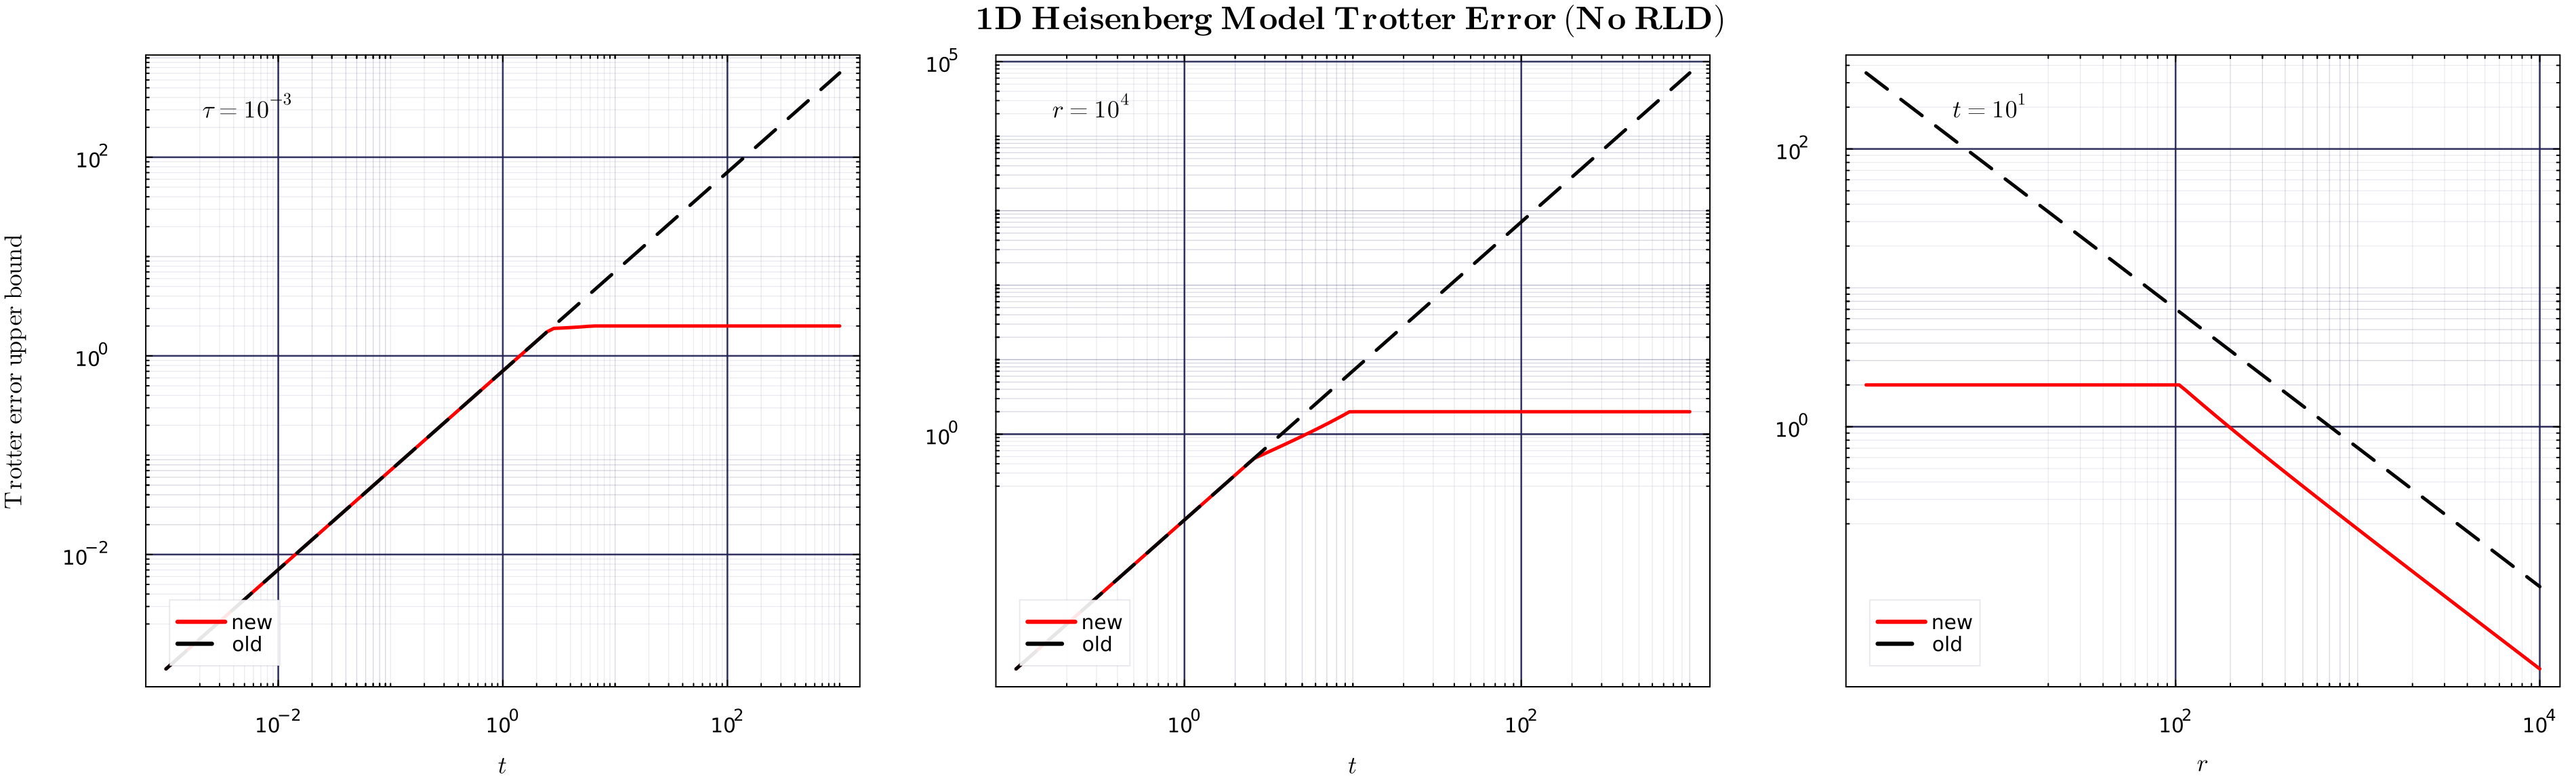

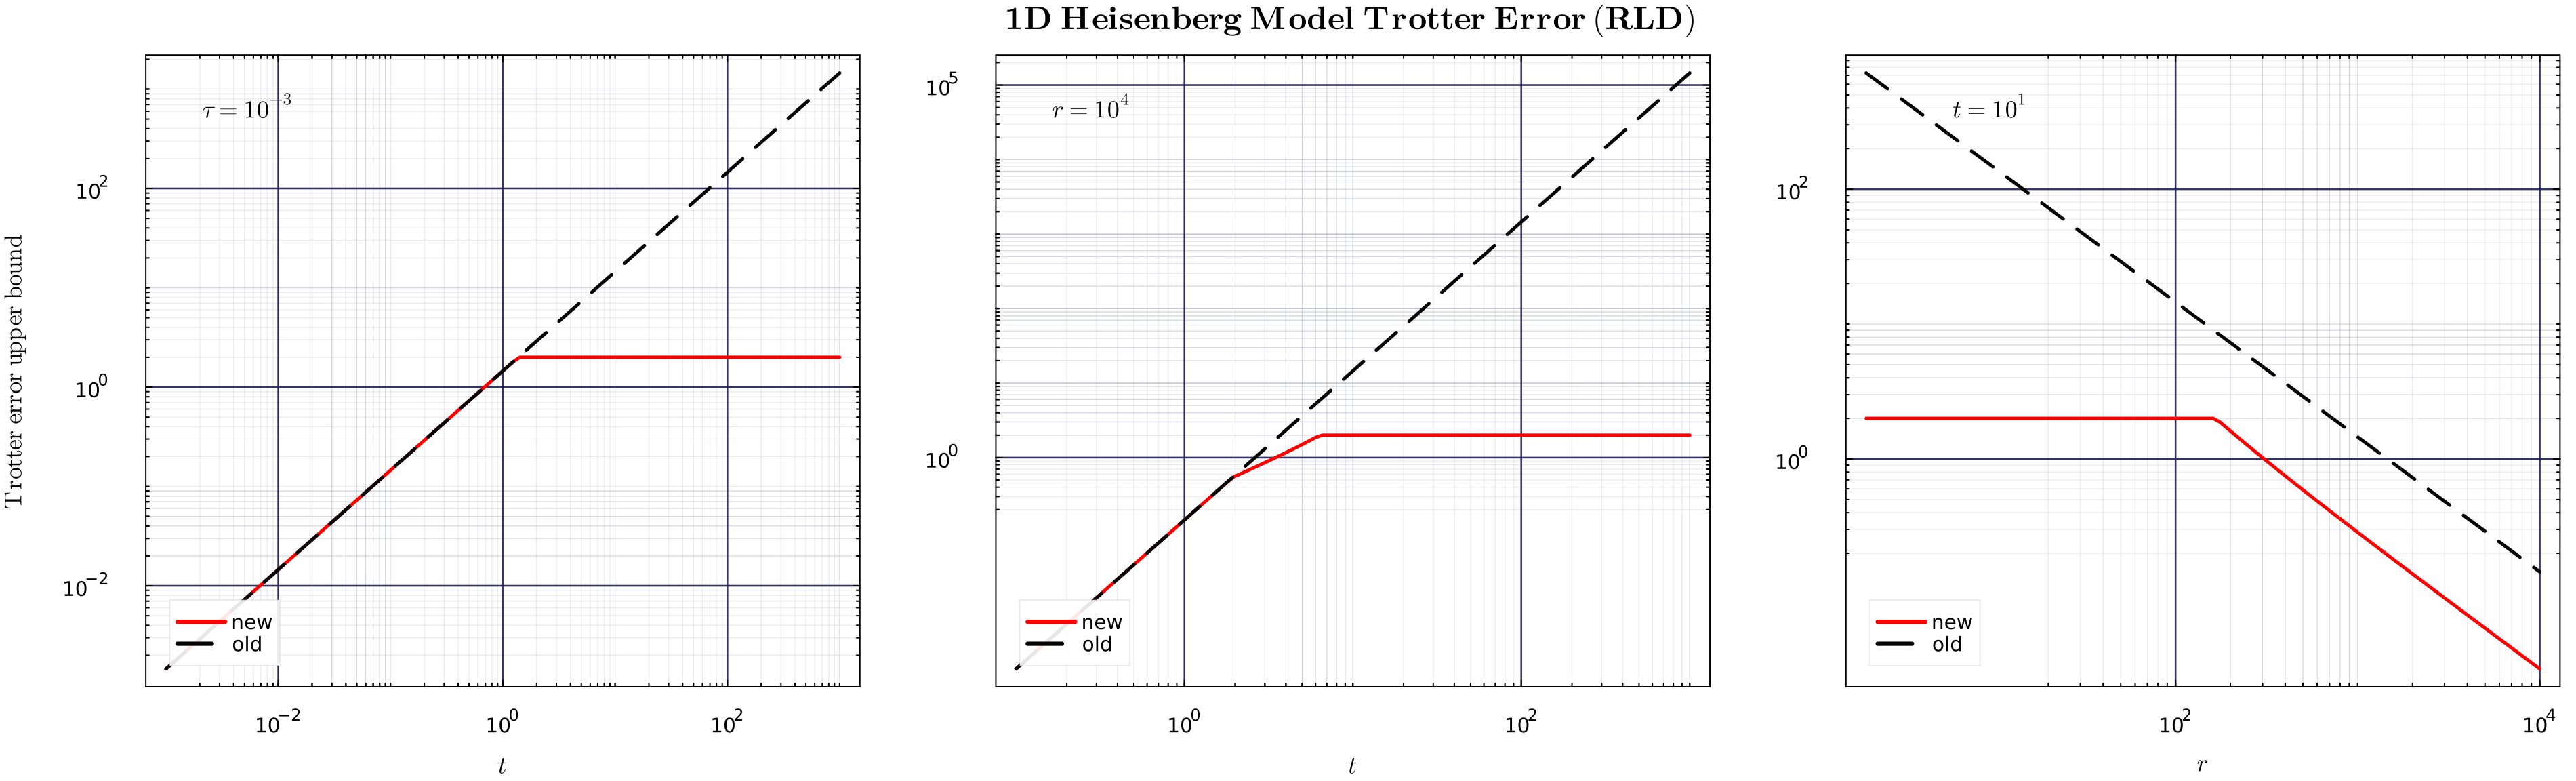

In [47]:
plt_bounds = trotter_error_plots(
    tvec_tau, errs_tau,    errs_old_tau,
    tvec_r,    errs_r,      errs_old_r,
    rvec,      errs_t,  errs_old_t;
    title = L"\textbf{1D\ Heisenberg\ Model\ Trotter\ Error\ ( No\ RLD )}",
    
    tau_text = L"\tau = 10^{-3}",
    r_text   = L"r = 10^{4}",
    t_text   = L"t = 10^{1}",
)

plt_bounds_RLD = trotter_error_plots(
    tvec_tau, errs_tau_RLD,    errs_old_tau_RLD,
    tvec_r,    errs_r_RLD,      errs_old_r_RLD,
    rvec,      errs_t_RLD,  errs_old_t_RLD;
    title = L"\textbf{1D\ Heisenberg\ Model\ Trotter\ Error\ ( RLD )}",
    
    tau_text = L"\tau = 10^{-3}",
    r_text   = L"r = 10^{4}",
    t_text   = L"t = 10^{1}",
)


display(plt_bounds)
display(plt_bounds_RLD)